<h1 style="font-size: 40px; margin-bottom: 0px;">3.2 Modeling biological phenomena (II)</h1>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 800px;"></hr>

Today, we'll continue to practice modeling dynamic biological processes, and then we'll begin gradually exploring slightly more complicated models using Python.

<strong>Learning objectives:</strong>
<ul>
    <li>Continue to practice for-loops and plotting</li>
    <li>Simulate dynamic processes over time using Python</li>
    <li>Simulating steady-state dynamics</li>
    <li>Modeling probabilistic phenomenon</li>
</ul>

In [2]:
#Import packages to use
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#These will allow us to poke around with performance and object sizes
import time
import sys

<h1 style="font-size: 40px; margin-bottom: 0px;">Exercise #1: Changing time step size (<code>dt</code>)</h1>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 850px;"></hr>

Something you may have noticed is that changing <code>dt</code> was excluded from the notebook 3.1 exercise #10. This is because there are additional considerations when adjusting <code>dt</code>, our step size for time. In this exercise, see if you can specifically change our <code>dt</code> parameter that we have kept at 1 minute so far. What happens when your <code>dt</code> is set to be greater than 1? What about when it is less than one?

In [2]:
#Let's set up our computational model the way we've been doing from 3-1
#But in this case, we'll change dt to a number that is not 1
t_max = 200 #minutes
dt = 2 #minutes
N = np.zeros(int(t_max/dt))
N[0] = 5 #bacteria
k = 0.01 #divisions per min

for t in range(0, t_max - dt, dt):
    N[t + dt] = N[t] + N[t]*k*dt

#Since we use dt as our step size for our range() function, we end up running into various issues

plt.plot(N)

IndexError: index 100 is out of bounds for axis 0 with size 100

You'll likely have encountered an error when playing around with the <code>dt</code> initial parameter. Recall back to notebook 3-1, to identify a way to adjust how you set up your for-loop so that you can change <code>dt</code> and still run your simulation for bacterial growth.

(0.0, 201.0)

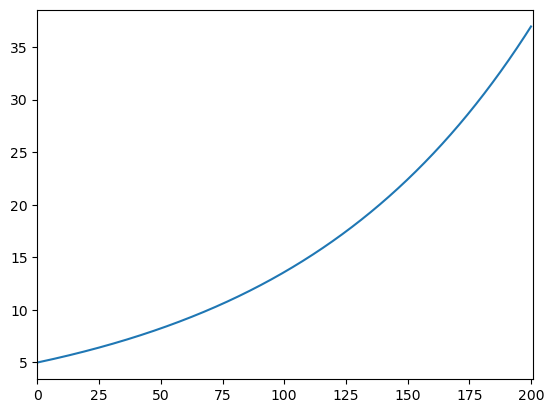

In [11]:
#So then we have to adjust how we set up our computational model
t_max = 200 #minutes
dt = 0.001 #minutes
N = np.zeros(int(t_max/dt))

#We have to change the object we iterate through
#So that we still move through each position 0,1,2,3... of our arrays
#while accounting for our t_max and our dt
position_list = range(0, int(t_max/dt) - 1, 1)

N[0] = 5 #bacteria
k = 0.01 #divisions per min

#Since our dt is no longer just 1
#Our time values won't neatly map to 0,1,2,3...
#So we need to separately calculate what our time values are
#for each "observation" or calculation we make
time_values = np.zeros(int(t_max/dt))


#So we have 2 expressions that we're solving in our for-loop
#one for the number of bacteria and the other for our time values
for t in position_list:
    N[t + 1] = N[t] + N[t]*k*dt
    time_values[t + 1] = time_values[t] + dt

plt.plot(time_values, N)
plt.xlim(0, 201)

How would we then adjust how we plot our results? Give it a try below to plot the results of your simulation.

(0.0, 201.0)

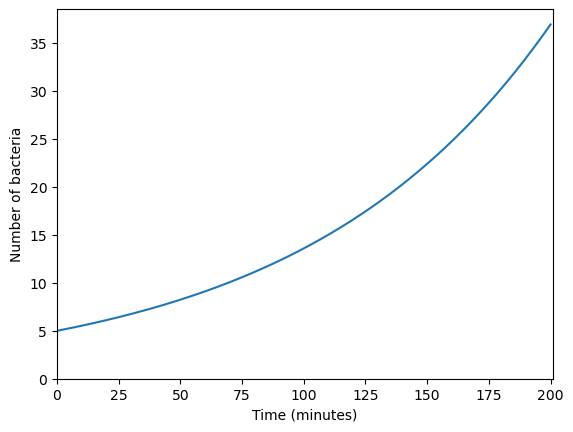

In [12]:
#So when we plot, we'll plot our time values on the x-axis
#and we'll plot our number of bacteria on our y-axis
plt.plot(time_values, N)
plt.ylabel('Number of bacteria')
plt.xlabel('Time (minutes)')
plt.ylim(0)
plt.xlim(0, 201)

<h1 style="font-size: 40px; margin-bottom: 0px;">Exercise #2: Overlay multiple simulations</h1>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 850px;"></hr>

This exercise will be a bit of a mix of simulation practice and also plotting. To make things easier, first set up a function that can run your bacterial growth simulation while allowing you to adjust the initial parameters.

In [3]:
#We can set up a quick function that will allow us to adjust parameters easily and rerun simulations
def bacterial_sim(t_max, dt, N_0, k):
    N = np.zeros(int(t_max/dt))

    position_list = range(0, int(t_max/dt) - 1, 1)

    time_values = np.zeros(int(t_max/dt))

    N[0] = N_0

    for t in position_list:
        N[t + 1] = N[t] + N[t]*k*dt
        time_values[t + 1] = time_values[t] + dt

    return time_values, N

Now run three simulations changing various parameters and generate a plot where you overlay each of the three simulations.

In [19]:
#Testing it out with various parameters to see how it runs and how the output changes
x1, y1 = bacterial_sim(t_max=200, dt=1, N_0=5, k=0.02) 
x2, y2 = bacterial_sim(t_max=200, dt=0.01, N_0=5, k=0.02)
x3, y3 = bacterial_sim(t_max=200, dt=5, N_0=100, k=0.002)

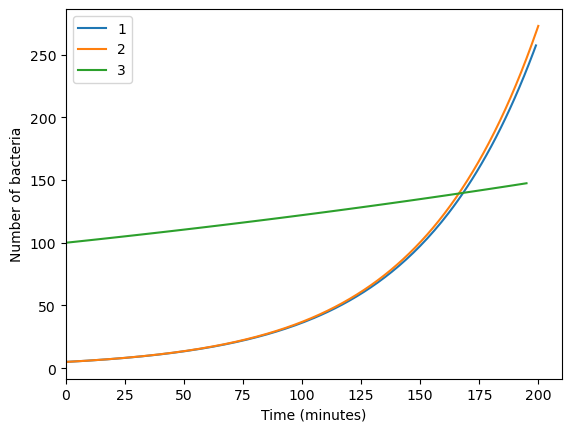

In [21]:
#Plot the results
fig, ax = plt.subplots()

plt.plot(x1, y1, label='1')
plt.plot(x2, y2, label='2')
plt.plot(x3, y3, label='3')

plt.legend()
plt.xlim(0)

plt.ylabel('Number of bacteria')
plt.xlabel('Time (minutes)')

plt.show()

Now what happens if you keep all starting parameters the same, but only change <code>dt</code> for three simulations? What happens when you run three simulations each with <code>dt</code> that are an order of magnitude or more in difference?

In [22]:
#Here we'll keep everything the same except for dt
#So "biologically" we're not changing anything, just changing how often we perform a calculation
x1, y1 = bacterial_sim(t_max=200, dt=1, N_0=5, k=0.02)
x2, y2 = bacterial_sim(t_max=200, dt=0.005, N_0=5, k=0.02)
x3, y3 = bacterial_sim(t_max=200, dt=5, N_0=5, k=0.02)

Let's take a look at the results of our simulations.

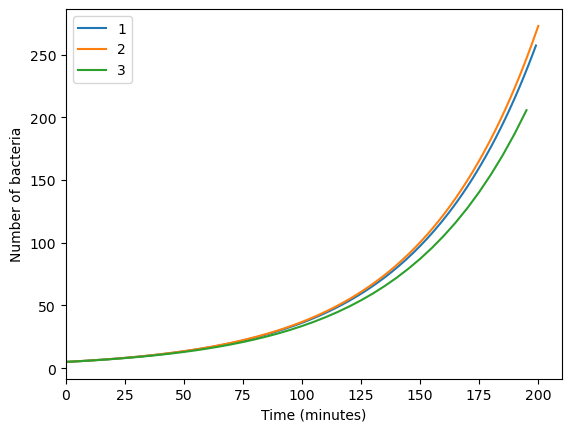

In [23]:
fig, ax = plt.subplots()

plt.plot(x1, y1, label='1')
plt.plot(x2, y2, label='2')
plt.plot(x3, y3, label='3')

plt.legend()
plt.xlim(0)

plt.ylabel('Number of bacteria')
plt.xlabel('Time (minutes)')

plt.show()

#When you plot your results, you'll then see that while we don't change anything "biological"
#we end up with different outputs based on what we set as our dt

<h1 style="font-size: 40px; margin-bottom: 0px;">Considerations for <code>dt</code> step size</h1>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 600px;"></hr>

If you take a look at our three simulations where we only changed the <code>dt</code>, you can see that the results of the simulation ended up fairly different from one another. Which one is more reflective of real biology? Our rate of division has not been changed, only our <code>dt</code>. Yet from our simulation, we now see that the simulations diverge from one another. From what we know, if our rate of division and our number of starting bacteria is unchanged, it shouldn't matter how often we take a timepoint. But in our computational simulations, we can see that it makes a difference in our calculations.

This sort of issue that we're seeing, which is an issue for computational simulations of biological processes, is called an integration error or dt error. When modeling biological phenomenon by solving ordinary differential equations as we have been doing, a source of error is the <code>dt</code> time step. Although earlier we referred to our <code>dt</code> as how often we're "observing" our <i>in silico</i> bacteria, we are really just predicting the number of bacteria expected to be at each time point. 

We know that biological processes are continuous, and our computational simulation can only perform a finite number of calculations, meaning that it can only advance in "time" in discrete intervals. Therefore, unlike the mathematical expressions that we solved in notebook 3-1, the calculation at each time point is dependent on the results of the previous time point, which means that differences in "sampling" intervals will affect the simulation. Recall from your calculus classes and when you learned Riemann's sums, and how the interval affects the accuracy of your estimation vs calculating the derivative. What we see with integration errors is similar, where a <code>dt</code> that is too large will not be able to accurately model the system.

In short, when setting up simulations, you need to consider the effect of your step size on your simulation because like how the interval size for a Riemann's sum affects how accurately it estimates a continuous interval, your step size will also affect your model's ability to predict/simulate real-world processes.

Let's take a look in the code cell below using our bacteria growth function that we set up earlier.

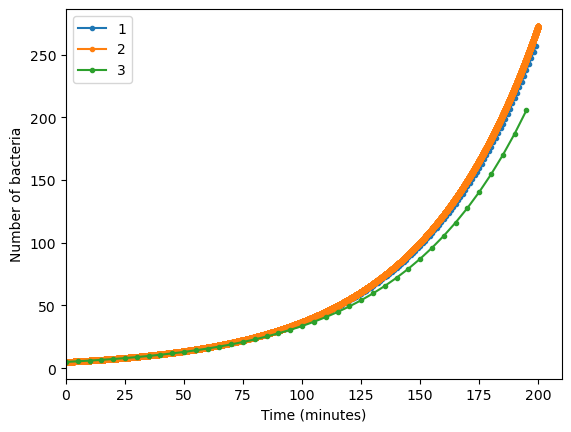

In [24]:
x1, y1 = bacterial_sim(t_max=200, dt=1, N_0=5, k=0.02)
x2, y2 = bacterial_sim(t_max=200, dt=0.005, N_0=5, k=0.02)
x3, y3 = bacterial_sim(t_max=200, dt=5, N_0=5, k=0.02)

#Same simulation but just changing how we plot to add markers to our line plot
#So we can see the frequency of calculations for each simulation

fig, ax = plt.subplots()

plt.plot(x1, y1, marker='.', label='1')
plt.plot(x2, y2, marker='.', label='2')
plt.plot(x3, y3, marker='.', label='3')

plt.legend()
plt.xlim(0)

plt.ylabel('Number of bacteria')
plt.xlabel('Time (minutes)')

plt.show()

We need to also consider the dynamics of the system we're modeling relative to our step size. Let's now hold step size constant but change the rate of bacterial division in a few simulations. 

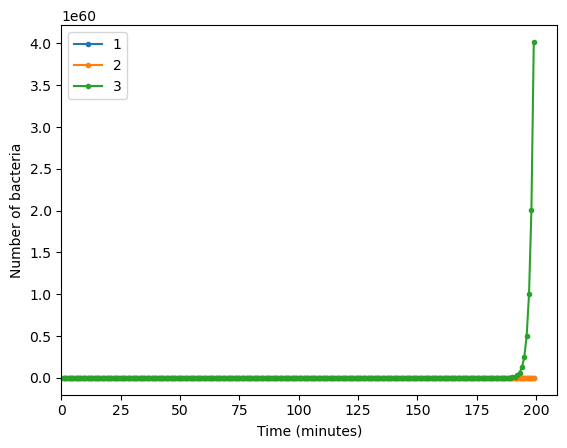

In [25]:
#Something to consider for dt is whether it is small enough to capture the dynamics of what you're modeling
#If it isn't, then you will be losing information and your simulation will deviate in unintended ways
x1, y1 = bacterial_sim(t_max=200, dt=1, N_0=5, k=0.02)
x2, y2 = bacterial_sim(t_max=200, dt=1, N_0=5, k=0.01)
x3, y3 = bacterial_sim(t_max=200, dt=1, N_0=5, k=1)

fig, ax = plt.subplots()

plt.plot(x1, y1, marker='.', label='1')
plt.plot(x2, y2, marker='.', label='2')
plt.plot(x3, y3, marker='.', label='3')

plt.legend()
plt.xlim(0)

plt.ylabel('Number of bacteria')
plt.xlabel('Time (minutes)')

plt.show()

You can see that it's the relationship between the rate in which our dynamic process is occurring relative to our simulations step size that impacts the accuracy of our simulation. For our bacterial growth model, our prediction's accuracy is therefore dependent upon the rate of bacterial division and how frequently we perform our calculations. 

It's tempting to simply then have a very, very small <code>dt</code> that is many orders of magnitude smaller than your fastest dynamic process that you're trying to simulate. However, you will also need to balance the computational burden that a really small <code>dt</code> will create since you will greatly increase the number of calculations that you are performing. Something slightly less intuitive that you also need to consider is that with very small <code>dt</code>, rounding error will eventually limit how accurate your calculations can be. Recall that the way floats are represented in Python result in small inaccuracies, so at some point, these inaccuracies limit the exactness of your calculations.

Generally, you don't want a step that is too small, which can slow down your simulations because you are performing too many calculations that don't really reduce the error of your model in a meaningful way, and you don't want a step size that is too large, which could lead to integration errors. And a helpful rule of thumb is to keep halving your <code>dt</code> until your simulation estimatations remain roughly the same, within some acceptable error. Let's give that a try in the below exercise.

<h1 style="font-size: 40px; margin-bottom: 0px;">Exercise #3: Sequentially halving <code>dt</code></h1>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 800px;"></hr>

For this exercise, see if you can make use of your bacterial growth function that you defined earlier along with what you know about for-loops and plotting to see if you can set up a for-loop where you sequentially halve your <code>dt</code> and plot the results of your simulation each time overlaid over the previous simulation.

Time to run simulation # 1: 0.0129 sec
Size of array object after simulation # 1: 1712

Time to run simulation # 2: 0.0002 sec
Size of array object after simulation # 2: 3312

Time to run simulation # 3: 0.0005 sec
Size of array object after simulation # 3: 6512

Time to run simulation # 4: 0.0008 sec
Size of array object after simulation # 4: 12912

Time to run simulation # 5: 0.0017 sec
Size of array object after simulation # 5: 25712

Time to run simulation # 6: 0.0033 sec
Size of array object after simulation # 6: 51312

Time to run simulation # 7: 0.0068 sec
Size of array object after simulation # 7: 102512

Time to run simulation # 8: 0.0133 sec
Size of array object after simulation # 8: 204912

Time to run simulation # 9: 0.0265 sec
Size of array object after simulation # 9: 409712

Time to run simulation # 10: 0.0536 sec
Size of array object after simulation # 10: 819312

Time to run simulation # 11: 0.1059 sec
Size of array object after simulation # 11: 1638512

Time to run si

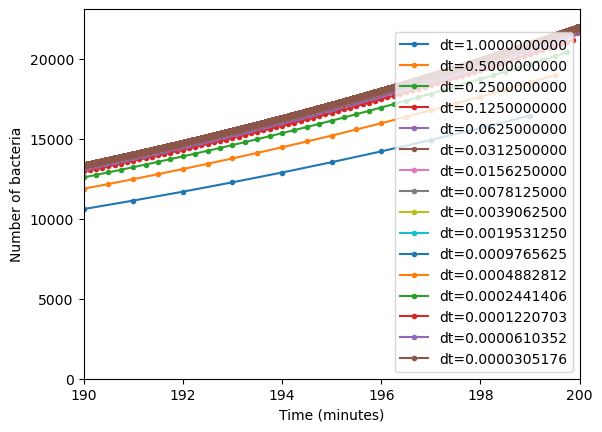

In [6]:
plt.close()

#Here we'll just run a lot of simulations but halve the dt each time
#Since we can only perform a finite number of calculations, there is a tradeoff to consider
#Where simulations will take longer if we have to perform more calculations, but it will be more accurate
#But after a point, the time and memory cost is no longer worth the smaller and smaller increase in accuracy

#So when determining what is a "good" dt, you can decide that based on time and memory costs and whether reducing dt more will be worth that tradeoff

fig, ax = plt.subplots()

for i in range(0, 16, 1):
    start_time = time.perf_counter()

    dt = 1/(2**i)

    x, y = bacterial_sim(200, dt, 1, 0.05)

    end_time = time.perf_counter()

    print(f'Time to run simulation # {i + 1}: {end_time - start_time:.4f} sec')
    print(f'Size of array object after simulation # {i + 1}: {sys.getsizeof(y)}\n')

    plt.plot(x, y, marker='.', label=f'dt={dt:.10f}')

plt.legend()
plt.xlim(190, 200)
plt.ylim(0)
plt.xlabel('Time (minutes)')
plt.ylabel('Number of bacteria')
plt.show()



What you should be able to see is that the simulation takes longer and longer to run and also demands much more memory when we use much much smaller step sizes with a diminishing benefit in terms of how much more accurate our simulation is, .

Recall that we can also set up for-loops and generate usable outputs using lists instead of arrays; however, lists are more memory-intensive as a result of how they store and access elements. Let's set up our final simulation with the smallest dt we used and compare the compute time and memory usage.

In [7]:
print(i)

15


In [8]:
t_max =200
dt = 1/(2**15)
N = []
N.append(1)
k=0.05
time_values = []
time_values.append(0)
position_list = range(0, int(t_max/dt) - 1, 1)

start_time = time.perf_counter()

for t in position_list:
    calculation = N[t] + N[t]*k*dt
    N.append(calculation)
    time_values.append(dt*t)

end_time = time.perf_counter()

print(f'Time to run simulation: {end_time - start_time:.4f} sec')
print(f'Size of array object after simulation: {sys.getsizeof(N)}\n')

#We can work with a list faster than an array but the memory cost is higher due to how lists are stored in memory vs arrays
#and arrays also allow us to perform math operations on the whole array more easily

Time to run simulation: 1.4670 sec
Size of array object after simulation: 55621560



<h1 style="font-size: 40px; margin-bottom: 0px;">Exercise #4: Model logistic growth</h1>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 700px;"></hr>

Let's try to simulate what happens when the environment that our <i>in silico</i> bacteria has a carrying capacity <code>K</code>, which dynamically affects the rate of bacterial proliferation, with reduced rates of proliferation as the population reaches the carrying capacity.

We know from Verhulst that logistic growth can be modeled with the following differential equation:

```
dN/dt = N(t)*r*(1- N(t)/K)
```

Where we use <code>r</code> as the rate of division, so it's not confused with <code>K</code> (capital K) for the carrying capacity.

See if you can figure out how to translate this differential equation into an expression that we can use to model logistic growth of our bacteria.

In [10]:
#Here we'll play around with logistic growth
#So like exponential growth, we can solve the equation for logistic growth
#and then translate it into Python code to run as a simulation

t_max = 1000 #minutes
dt = 0.005 #minutes
N = np.zeros(int(t_max/dt))
N[0] = 1 #bacteria
r = 0.01 #divisions per minute
K = 200 #bacteria

position_list = range(0, int(t_max/dt) - 1, 1)
time_array = np.zeros(int(t_max/dt))

for t in position_list:
    N[t + 1] = N[t] + N[t]*r*dt*(1 - N[t]/K)
    time_array[t + 1] = time_array[t] + dt

Text(0, 0.5, 'Number of bacteria')

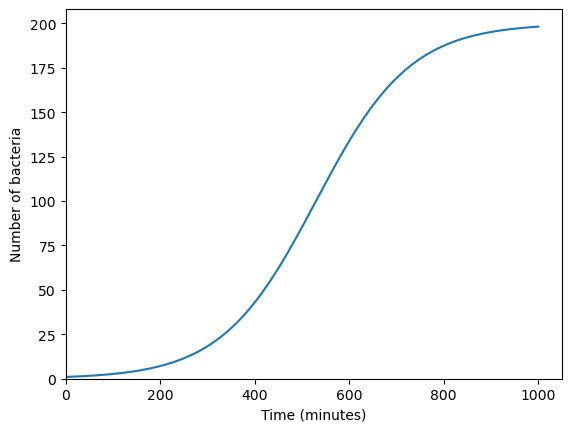

In [11]:
plt.plot(time_array, N)

plt.xlim(0)
plt.ylim(0)

plt.xlabel('Time (minutes)')
plt.ylabel('Number of bacteria')

<h1 style="font-size: 40px; margin-bottom: 0px;">Exercise #5: Simulate mRNA dynamics</h1>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 800px;"></hr>

Like with bacterial growth, we can also simulate the levels of mRNA. We know that mRNA is produced at some constant rate <code>r</code>. And we know that mRNA will have some rate of decay <code>gamma</code> that is dependent on the levels of mRNA (if there's no mRNA, then there's nothing to decay). So after some given time step <strong>C(t+dt)</strong>, we can model the levels of mRNA by taking into account the number of mRNA that we had at the previous timepoint <strong>C(t)</strong>, how many mRNA were made in the interval <strong>(r times dt)</strong>, and how many decayed <strong>(gamma times dt times C(t))</strong>.

That gives us the following equation:

```
C(t+dt) = C(t) + r*dt - gamma*dt*C(t)
```

See if you can use that equation to then simulate mRNA dynamics with the initial parameters given in the code cell below:

In [12]:
#We can also simulate mRNA steady state dynamics

t_max = 5 #minutes
dt = 0.001 #minutes
r = 50 #mRNA made per minute
gamma = 2 #rate of mRNA decay per minute per mRNA

mRNA_low = np.zeros(int(t_max/dt))
mRNA_low[0] = 5 #mRNA molecules to begin with 

position_list = range(0, int(t_max/dt) - 1, 1)
time_array = np.zeros(int(t_max/dt))

for t in position_list:
    mRNA_low[t + 1] = mRNA_low[t] + r * dt - gamma * dt * mRNA_low[t]
    time_array[t + 1] = time_array[t] + dt

Now let's plot the results of our simulation.

(0.0, 25.999054208971426)

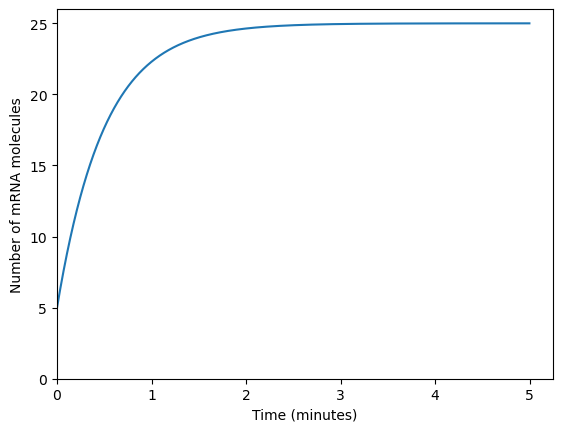

In [15]:
plt.plot(time_array, mRNA_low)

plt.xlabel('Time (minutes)')
plt.ylabel('Number of mRNA molecules')
plt.xlim(0)
plt.ylim(0)

#So when we have low numbers of mRNA,
#the rate of mRNA production is greater than the rate of mRNA decay
#so our simulation increases until it reaches steady state (when mRNA production = mRNA decay)

Now what if we have a starting mRNA number of 40? How does that change the dynamics of our mRNA?

In [16]:
#Here we start with a high number of mRNA to begin with

t_max = 5 #minutes
dt = 0.001 #minutes
r = 50 #mRNA made per minute
gamma = 2 #rate of mRNA decay per minute per mRNA

mRNA_high = np.zeros(int(t_max/dt))
mRNA_high[0] = 40 #mRNA molecules to begin with 

position_list = range(0, int(t_max/dt) - 1, 1)
time_array = np.zeros(int(t_max/dt))

for t in position_list:
    mRNA_high[t + 1] = mRNA_high[t] + r * dt - gamma * dt * mRNA_high[t]
    time_array[t + 1] = time_array[t] + dt

Now plot the results of your new simulation.

(0.0, 40.74996622174895)

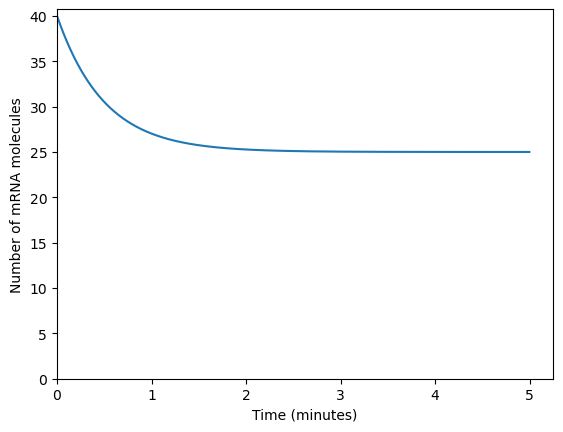

In [17]:
plt.plot(time_array, mRNA_high)

plt.xlabel('Time (minutes)')
plt.ylabel('Number of mRNA molecules')
plt.xlim(0)
plt.ylim(0)

#What you'll see is that with the same equation,
#our mRNA levels will decay until it reaches steady state
#since the rate of mRNA decay will be greater than the rate of mRNA production
#and once at steady state, the two rates will be equal again so the line flattens out

How does the plot look in comparison to when the starting level of mRNA was at 5 mRNA molecules? Go ahead and overlay both simulation results.

(0.0, 41.75)

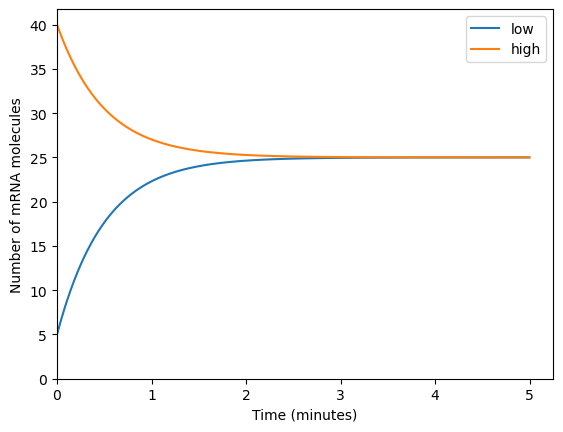

In [18]:
#We can visualize both plots together to more readily see how that looks like and where steady-state is for our parameters

fig, ax = plt.subplots()

plt.plot(time_array, mRNA_low, label='low')
plt.plot(time_array, mRNA_high, label='high')

plt.legend()
plt.xlabel('Time (minutes)')
plt.ylabel('Number of mRNA molecules')
plt.xlim(0)
plt.ylim(0)

<h1 style="font-size: 40px; margin-bottom: 0px;">Exercise #6: Simulating 1D diffusion via coin flips</h1>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 900px;"></hr>

Diffusion can be modeled using a random walk, where we essentially "flip a coin" to determine whether our molecule moves in one direction or another. To do this, you can make use of either <code>np.random.randint()</code> or a uniform random number generator <code>np.random.uniform()</code> along with a conditional statement.

<a href="https://numpy.org/doc/stable/reference/random/generated/numpy.random.randint.html" rel="noopener noreferrer" target="_blank"><u>Documentation for <code>np.random.randint()</code> can be found here.</u></a>

<a href="https://numpy.org/doc/stable/reference/random/generated/numpy.random.uniform.html" rel="noopener noreferrer" target="_blank"><u>Documentation for <code>np.random.uniform()</code> can be found here.</u></a>

See if you can set up a random number generator to model one-dimensional diffusion using what you learned in this notebook and what you know about conditional statements to control how code is executed. You can assume that the molecule can only move in one direction or the other when setting up your simulation.

Once you have your simulation set up, plot the results of your simulation.

<h1 style="font-size: 40px; margin-bottom: 0px;">Challenge #1: Model multiple molecules simultaneously</h1>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 950px;"></hr>

For those of you working ahead or would like additional practice/something more challenging. The portions from this point on will expand on what we've been doing and adding a layer of complexity. 

See if you can take what you know to set up a nested for-loop that will allow you to model the 1D diffusion of multiple molecules simultaneously using the coin flip method you used in exercise 6.

You'll need to set up in this case, a 2D array (a matrix) where each row corresponds to the position of a single molecule and each column corresponds to individual molecules. So the matrix will look something like this table:

<table>
    <tr style="background-color: transparent; border: none;">
        <td style="background-color: transparent; border: none;"></td>
        <td style="background-color: #EEEEEE; border: 1px solid; border-color: #000000;">Mol_1</td>
        <td style="background-color: #EEEEEE; border: 1px solid; border-color: #000000;">Mol_2</td>
        <td style="background-color: #EEEEEE; border: 1px solid; border-color: #000000;">Mol_3</td>
        <td style="background-color: #EEEEEE; border: 1px solid; border-color: #000000;">Mol_4</td>
    </tr>
    <tr style="background-color: transparent; border: 1px solid; border-color: #000000;">
        <td style="background-color: #EEEEEE; border: 1px solid; border-color: #000000;">Flip_1</td>
        <td style="background-color: transparent; border: 1px solid; border-color: #000000;">&nbsp;</td>
        <td style="background-color: transparent; border: 1px solid; border-color: #000000;">&nbsp;</td>
        <td style="background-color: transparent; border: 1px solid; border-color: #000000;">&nbsp;</td>
        <td style="background-color: transparent; border: 1px solid; border-color: #000000;">&nbsp;</td>
    </tr>
        <tr style="background-color: transparent; border: 1px solid; border-color: #000000;">
        <td style="background-color: #EEEEEE; border: 1px solid; border-color: #000000;">Flip_2</td>
        <td style="background-color: transparent; border: 1px solid; border-color: #000000;">&nbsp;</td>
        <td style="background-color: transparent; border: 1px solid; border-color: #000000;">&nbsp;</td>
        <td style="background-color: transparent; border: 1px solid; border-color: #000000;">&nbsp;</td>
        <td style="background-color: transparent; border: 1px solid; border-color: #000000;">&nbsp;</td>
    </tr>
    </tr>
        <tr style="background-color: transparent; border: 1px solid; border-color: #000000;">
        <td style="background-color: #EEEEEE; border: 1px solid; border-color: #000000;">Flip_3</td>
        <td style="background-color: transparent; border: 1px solid; border-color: #000000;">&nbsp;</td>
        <td style="background-color: transparent; border: 1px solid; border-color: #000000;">&nbsp;</td>
        <td style="background-color: transparent; border: 1px solid; border-color: #000000;">&nbsp;</td>
        <td style="background-color: transparent; border: 1px solid; border-color: #000000;">&nbsp;</td>
    </tr>
    </tr>
        <tr style="background-color: transparent; border: 1px solid; border-color: #000000;">
        <td style="background-color: #EEEEEE; border: 1px solid; border-color: #000000;">Flip_4</td>
        <td style="background-color: transparent; border: 1px solid; border-color: #000000;">&nbsp;</td>
        <td style="background-color: transparent; border: 1px solid; border-color: #000000;">&nbsp;</td>
        <td style="background-color: transparent; border: 1px solid; border-color: #000000;">&nbsp;</td>
        <td style="background-color: transparent; border: 1px solid; border-color: #000000;">&nbsp;</td>
    </tr>
    </tr>
        <tr style="background-color: transparent; border: 1px solid; border-color: #000000;">
        <td style="background-color: #EEEEEE; border: 1px solid; border-color: #000000;">Flip_5</td>
        <td style="background-color: transparent; border: 1px solid; border-color: #000000;">&nbsp;</td>
        <td style="background-color: transparent; border: 1px solid; border-color: #000000;">&nbsp;</td>
        <td style="background-color: transparent; border: 1px solid; border-color: #000000;">&nbsp;</td>
        <td style="background-color: transparent; border: 1px solid; border-color: #000000;">&nbsp;</td>
    </tr>
</table>

Let's generate a plot of all our molecules as they move through 1D space over time.

We can adjust our plot parameters to reduce the opacity of each line and then change the color to black. This will give us a visual idea of the distribution based on the degree of overlap.

Let's now visualize the distribution as a histogram.

We can also plot the distribution as a simulated cumulative distribution function, where the X-axis is the position of a molecule in space, and the Y-axis is the sorted molecule or the proportion of molecules before that position on the X-axis.

<h1 style="font-size: 40px; margin-bottom: 0px;">Challenge #2: Simulate mRNA dynamics in response to an oscillating transcription factor</h1>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 950px;"></hr>

See if you can try to come up with an ad hoc simulation of mRNA dynamics when mRNA is only produced once a transcription factor reaches some threshold concentration. For this, we can make use of the <code>np.sin()</code> function to represent oscillating levels of a theoretical transcription factor.

<a href="https://numpy.org/doc/stable/reference/generated/numpy.sin.html" rel="noopener noreferrer"><u>Documentation for <code>np.sin()</code> can be found here.</u></a>

We can make use of our mRNA steady-state equation:

```
C(t+dt) = C(t) + r*dt - gamma*dt*C(t)
```

And then incorporate an interaction where rate of mRNA production is also dependent on the efficiency of transcription factor binding and activation.

```
C(t+dt) = C(t) + r*c*dt - gamma*dt*C(t)
```

Where lowercase <code>c</code> is the efficiency of transcription factor binding and activation to turn on transcription of the target mRNA.

What modifications could you potentially make if you wanted to then require a specific threshold concentration of transcription factor to be reached in order for transcription to occur?